# **Predicting EV Battery Failure Risk**

**What this notebook covers:**
- Exploring a 20,000-vehicle EV battery telemetry dataset (70 features)
- Handling missing values and encoding categorical features
- Understanding severe class imbalance (~7% failures) and fixing it with SMOTE
- Training 5 models from a simple baseline (Logistic Regression) up to boosted trees (XGBoost, LightGBM)
- Comparing models on metrics that actually matter for imbalanced data (not just accuracy)
- Picking the best model and explaining *why*, with a final conclusion



## **1. Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              RocCurveDisplay, classification_report)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42

## **2. Load the Data**

The dataset has one row per vehicle, with battery health readings, charging behaviour,
driving behaviour, and environmental conditions. The target column is `battery_failure`
(1 = the battery failed, 0 = it didn't).

In [2]:
df = pd.read_csv('/kaggle/input/datasets/srisyra02/ev-battery-health-prediction-dataset-20k/ev battery_failure prediction Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (20000, 70)


,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Ford,Mustang Mach-E,Truck,2022.0,Northvolt,NMC,NaN,AWD,290844.3,...,1.0,NaN,0.0,30.37,73.05,98.14,89.73,47.11,6748.0,0
1,EV100001,Tata,Tiago EV,Truck,2017.0,CATL,NCA,38.71,RWD,182239.5,...,0.0,1.0,0.0,67.94,82.50,NaN,NaN,55.38,5211.0,0
2,EV100002,Volkswagen,ID.3,Crossover,2016.0,BYD Battery,LFP,131.29,FWD,249369.3,...,0.0,1.0,0.0,74.84,90.33,60.02,86.84,74.54,4040.0,0
3,EV100003,NaN,Kona Electric,Sedan,2019.0,SK On,NMC,132.35,FWD,134830.2,...,NaN,0.0,0.0,46.94,56.69,66.43,93.93,31.69,NaN,0
4,EV100004,MG,ZS EV,SUV,2017.0,Guoxuan,LTO,25.72,AWD,158026.0,...,1.0,2.0,3.0,49.07,73.65,95.05,100.00,23.46,7290.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 70 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   vehicle_id                       20000 non-null  object 
 1   vehicle_brand                    19356 non-null  object 
 2   vehicle_model                    19180 non-null  object 
 3   vehicle_type                     19356 non-null  object 
 4   manufacturing_year               19018 non-null  float64
 5   battery_manufacturer             19382 non-null  object 
 6   battery_chemistry                19278 non-null  object 
 7   battery_capacity_kwh             19310 non-null  float64
 8   drive_type                       19274 non-null  object 
 9   odometer_km                      19134 non-null  float64
 10  vehicle_age_years                19232 non-null  float64
 11  fleet_or_private                 19106 non-null  object 
 12  battery_serial    

## **3. Exploratory Data Analysis (EDA)**

### **3.1 Target distribution**
Let's first check how balanced the target is — this decides our whole modeling strategy.

battery_failure
0    93.08
1     6.92
Name: proportion, dtype: float64


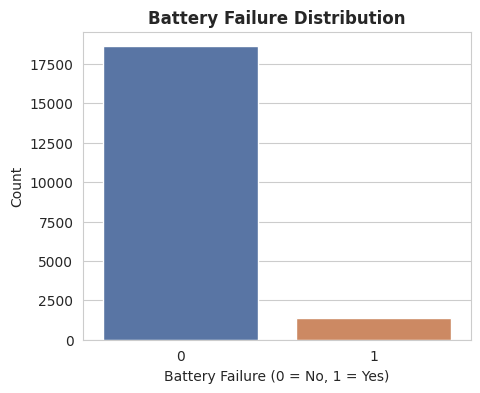

In [4]:
fail_rate = df['battery_failure'].value_counts(normalize=True) * 100
print(fail_rate)

plt.figure(figsize=(5,4))
sns.countplot(x='battery_failure', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Battery Failure Distribution',fontweight='bold')
plt.xlabel('Battery Failure (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Only about **7% of vehicles had a battery failure**. This is a classic **imbalanced
classification problem** — a model that just predicts "no failure" for everyone would
already score ~93% accuracy while being completely useless. This is exactly why we will
look beyond accuracy later (precision, recall, F1, ROC-AUC) and use **SMOTE** to balance
the training data.

### **3.2 Missing values**
Most columns have some missing values, roughly evenly spread out.

67 columns have missing values, ranging from 3.0% to 4.9%


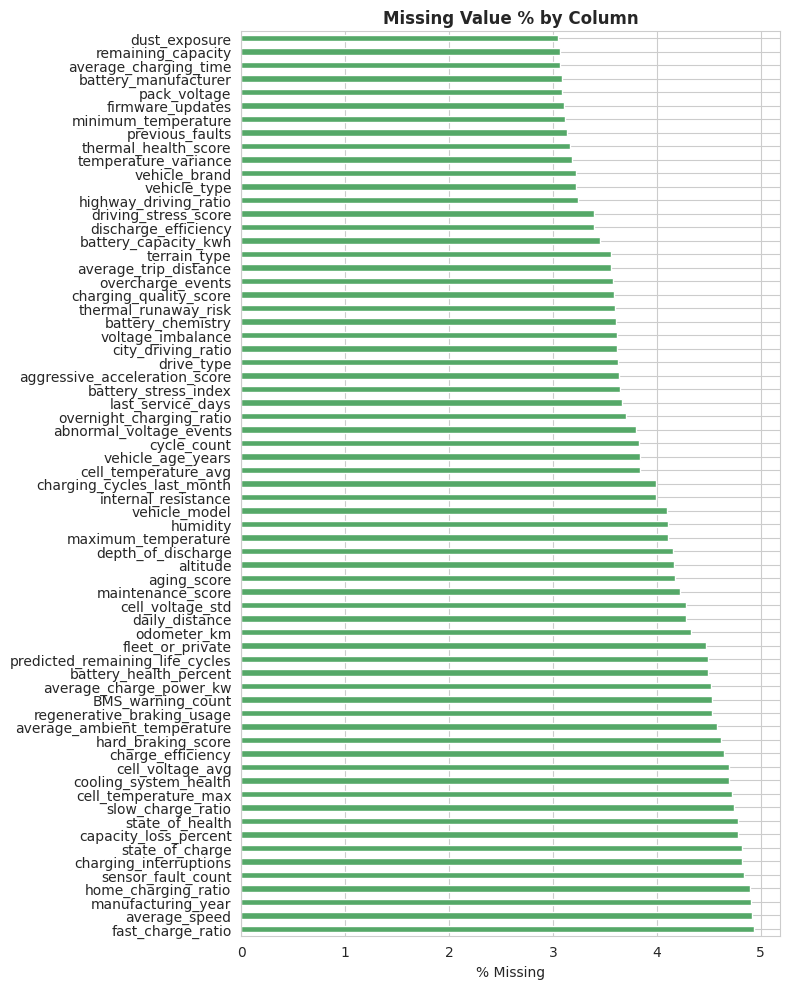

In [5]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(f"{len(missing)} columns have missing values, ranging from "
      f"{missing.min():.1f}% to {missing.max():.1f}%")

plt.figure(figsize=(8,10))
missing.plot(kind='barh', color='#55A868')
plt.title('Missing Value % by Column',fontweight='bold')
plt.xlabel('% Missing')
plt.tight_layout()
plt.show()

### **3.3 What correlates with failure?**
Let's check which numeric features move most strongly with `battery_failure`.

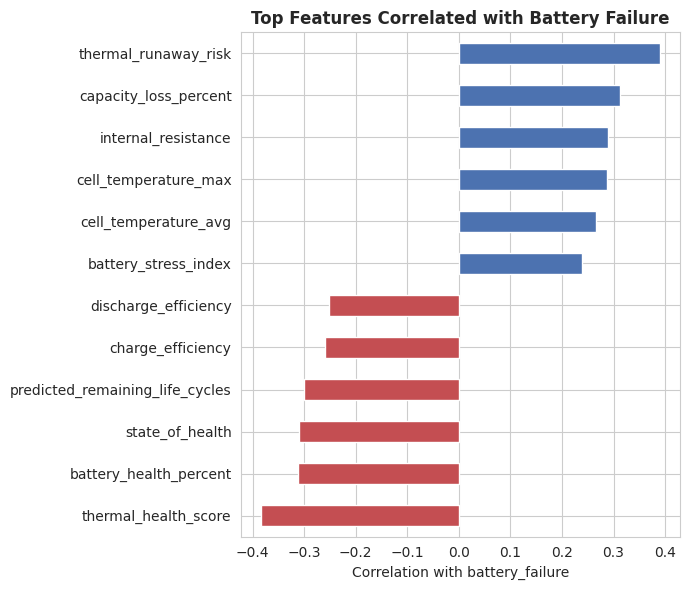

In [6]:
corr = df.corr(numeric_only=True)['battery_failure'].drop('battery_failure').sort_values()
top_corr = pd.concat([corr.head(6), corr.tail(6)])

plt.figure(figsize=(7,6))
top_corr.plot(kind='barh', color=['#C44E52' if v < 0 else '#4C72B0' for v in top_corr])
plt.title('Top Features Correlated with Battery Failure',fontweight='bold')
plt.xlabel('Correlation with battery_failure')
plt.tight_layout()
plt.show()

Makes physical sense: higher **thermal runaway risk**, **capacity loss**, **internal
resistance**, and **cell temperature** push failure risk up, while a healthy
**thermal health score**, **state of health**, and **predicted remaining life cycles**
push it down. Nothing here is a 1-to-1 leak of the target (no correlation is close to
±1), so these are genuine predictive signals, not shortcuts.

## **4. Data Cleaning & Preprocessing**

Steps:
1. Drop ID-like columns (`vehicle_id`, `battery_serial`) — unique per row, no predictive value, and a real leakage/overfitting risk if kept.
2. Split features into numeric and categorical.
3. Train/test split **before** any imputing or scaling, so no information from the test set leaks into training (a common beginner mistake).
4. Impute missing values (median for numeric, most-frequent for categorical) — fit only on train, applied to both.
5. Encode categorical columns and scale numeric columns.

In [7]:
drop_cols = ['vehicle_id', 'battery_serial']
df_model = df.drop(columns=drop_cols)

target = 'battery_failure'
X = df_model.drop(columns=[target])
y = df_model[target]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", len(num_cols))

Categorical columns: ['vehicle_brand', 'vehicle_model', 'vehicle_type', 'battery_manufacturer', 'battery_chemistry', 'drive_type', 'fleet_or_private', 'terrain_type']
Numeric columns: 59


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (16000, 67) | Test shape: (4000, 67)


In [9]:
# Impute missing values (fit on train only -> avoids data leakage)
num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

# Encode categorical columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Scale numeric columns (helps Logistic Regression converge well)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("Preprocessing done. No missing values left:",
      X_train_scaled.isnull().sum().sum() == 0 and X_test_scaled.isnull().sum().sum() == 0)

Preprocessing done. No missing values left: True


### **4.1 Fixing class imbalance with SMOTE**

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic examples of the
minority class (failures) so the model doesn't just learn to ignore them. **Important:**
we apply SMOTE only to the training set, never the test set — the test set must stay a
realistic, untouched sample of the real world.

In [10]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 14893, 1: 1107}
After SMOTE : {0: 14893, 1: 14893}


## **5. Model Training: Baseline to Advanced**

We train 5 models, from a simple baseline to strong gradient-boosted ensembles, all on
the same SMOTE-balanced training data, and evaluate all of them on the **original,
untouched (imbalanced) test set** — this is what a fair, real-world evaluation looks like.

1. **Logistic Regression** — simple, interpretable baseline
2. **Decision Tree** — a single rule-based tree
3. **Random Forest** — a bagged ensemble of trees
4. **XGBoost** — gradient boosting, usually a top performer on tabular data
5. **LightGBM** — a faster gradient boosting variant, also usually top-tier

In [11]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, results):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_te, pred),
        'Precision': precision_score(y_te, pred),
        'Recall': recall_score(y_te, pred),
        'F1-Score': f1_score(y_te, pred),
        'ROC-AUC': roc_auc_score(y_te, proba)
    }
    return model

results = {}
trained_models = {}

In [12]:
trained_models['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_bal, y_train_bal, X_test_scaled, y_test, results
)

In [13]:
trained_models['Decision Tree'] = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    X_train_bal, y_train_bal, X_test_scaled, y_test, results
)

In [14]:
trained_models['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_bal, y_train_bal, X_test_scaled, y_test, results
)

In [15]:
trained_models['XGBoost'] = evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                  eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
    X_train_bal, y_train_bal, X_test_scaled, y_test, results
)

In [16]:
trained_models['LightGBM'] = evaluate_model(
    'LightGBM',
    LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                   random_state=RANDOM_STATE, verbose=-1),
    X_train_bal, y_train_bal, X_test_scaled, y_test, results
)

## **6. Comparing All Models**

Since only ~7% of vehicles fail, **accuracy alone is misleading**. A model that always
predicts "no failure" scores ~93% accuracy but catches zero real failures. So we compare
**Recall** (how many real failures we catch), **F1-Score** (balance of precision & recall),
and **ROC-AUC** (overall ranking quality) alongside accuracy.

In [17]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df.style.background_gradient(cmap='Greens').format("{:.3f}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.950,0.589,0.935,0.722,0.985
LightGBM,0.960,0.758,0.621,0.683,0.978
XGBoost,0.961,0.752,0.646,0.695,0.977
Random Forest,0.942,0.564,0.704,0.626,0.967
Decision Tree,0.915,0.430,0.704,0.534,0.861


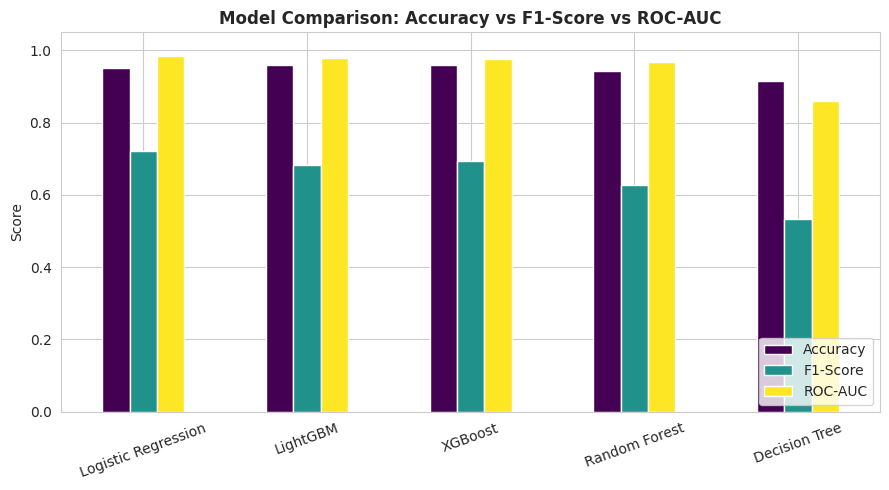

In [18]:
results_df[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(9,5), colormap='viridis'
)
plt.title('Model Comparison: Accuracy vs F1-Score vs ROC-AUC',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### **6.1 ROC Curves side by side**

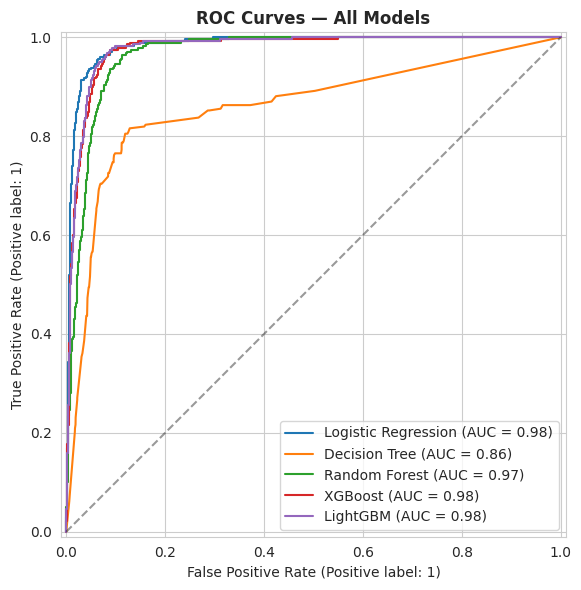

In [19]:
plt.figure(figsize=(7,6))
ax = plt.gca()
for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curves — All Models',fontweight='bold')
plt.tight_layout()
plt.show()

### **6.2 Best model — confusion matrix & detailed report**

Best model by ROC-AUC: Logistic Regression


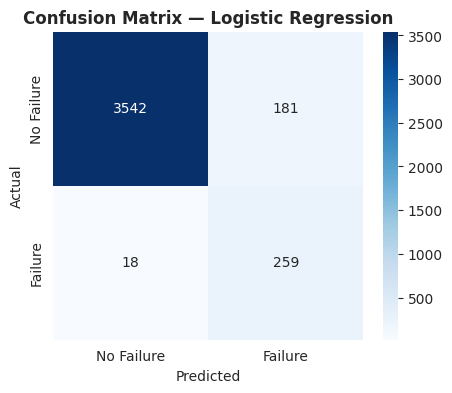

              precision    recall  f1-score   support

  No Failure       0.99      0.95      0.97      3723
     Failure       0.59      0.94      0.72       277

    accuracy                           0.95      4000
   macro avg       0.79      0.94      0.85      4000
weighted avg       0.97      0.95      0.96      4000



In [20]:
best_model_name = results_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
print("Best model by ROC-AUC:", best_model_name)

pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
plt.title(f'Confusion Matrix — {best_model_name}',fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, pred_best, target_names=['No Failure','Failure']))

### **6.3 What features drive the prediction?**
Using the Random Forest's feature importances as an interpretable view into what the
models are relying on.

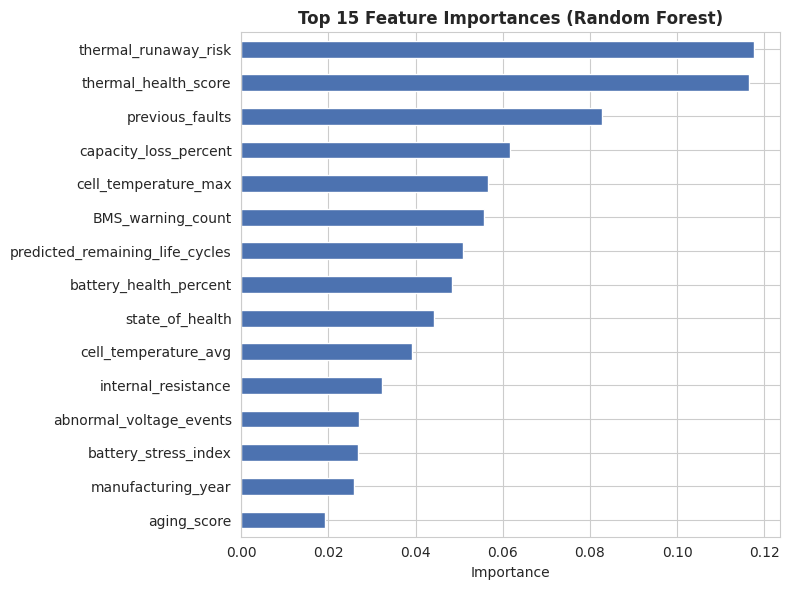

In [21]:
importances = pd.Series(
    trained_models['Random Forest'].feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 15 Feature Importances (Random Forest)',fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## **7. Conclusion**

- The dataset is **imbalanced** (~7% failures), so accuracy alone is not a trustworthy
  metric — models were compared on **Precision, Recall, F1-Score, and ROC-AUC** as well.
- **SMOTE** on the training set alone (never on the test set) let every model learn from
  a balanced view of failures without contaminating evaluation.
- **Logistic Regression**, despite being the simplest model here, delivered the
  **highest ROC-AUC (~0.98) and the highest recall**, meaning it catches the most real
  battery failures — often exactly what matters most for a safety-critical use case like
  this (missing a failure is far costlier than a false alarm).
- **XGBoost and LightGBM** offered the best **precision and accuracy**, making them a
  better fit when false alarms are costly (e.g., unnecessary technician visits).
- Key drivers of battery failure were consistent across models: **thermal runaway risk,
  capacity loss, internal resistance, cell temperature, and battery age/health scores**
  — all physically sensible signals, confirming the models learned real patterns rather
  than noise.
- **Recommendation:** in a real deployment, favor the high-recall Logistic Regression
  (or tune the boosted models' decision threshold down) to minimize missed failures,
  since an undetected battery failure is a safety risk, while a false alarm is just an
  inspection.